**Using synthetic data generated by Claude, I wanted to test run what a forecasting experience looks like for Norfolk Southern**

*Examine the generated data*

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv('ns_locomotive_sensors.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [33]:
#look at the hour index
df['hour'] = df.groupby('locomotive_id').cumcount()
print(f"Shape of the dataframe: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Locomotive IDs: {df['locomotive_id'].unique()}")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"Hours per locomotive: {df['hour'].max() + 1}")

Shape of the dataframe: 36000 rows and 13 columns
Locomotive IDs: ['NS-1001' 'NS-1002' 'NS-1003' 'NS-1004' 'NS-1005' 'NS-1006' 'NS-1007'
 'NS-1008' 'NS-1009' 'NS-1010' 'NS-1011' 'NS-1012' 'NS-1013' 'NS-1014'
 'NS-1015' 'NS-1016' 'NS-1017' 'NS-1018' 'NS-1019' 'NS-1020' 'NS-1021'
 'NS-1022' 'NS-1023' 'NS-1024' 'NS-1025' 'NS-1026' 'NS-1027' 'NS-1028'
 'NS-1029' 'NS-1030' 'NS-1031' 'NS-1032' 'NS-1033' 'NS-1034' 'NS-1035'
 'NS-1036' 'NS-1037' 'NS-1038' 'NS-1039' 'NS-1040' 'NS-1041' 'NS-1042'
 'NS-1043' 'NS-1044' 'NS-1045' 'NS-1046' 'NS-1047' 'NS-1048' 'NS-1049'
 'NS-1050']
Date range: 2026-01-01 to 2026-01-30
Hours per locomotive: 720


In [34]:
df.head(10)

,timestamp,locomotive_id,failure_type_true,coolant_temp_f,coolant_level_pct,battery_volts,oil_pressure_psi,engine_temp_f,rpm,ambient_temp_f,cooling_water_loss,battery_failure,hour
0,2026-01-01 00:00:00,NS-1001,none,177.64,97.82,14.193,63.45,182.94,801.7,59.75,0,0,0
1,2026-01-01 01:00:00,NS-1001,none,172.57,98.03,14.183,63.24,183.40,783.5,58.00,0,0,1
2,2026-01-01 02:00:00,NS-1001,none,176.41,98.73,14.191,63.46,185.05,829.8,51.85,0,0,2
3,2026-01-01 03:00:00,NS-1001,none,175.29,97.30,14.221,63.97,183.08,821.4,60.50,0,0,3
4,2026-01-01 04:00:00,NS-1001,none,178.01,98.82,14.158,64.86,185.34,791.9,52.37,0,0,4
5,2026-01-01 05:00:00,NS-1001,none,173.86,97.17,14.286,64.11,181.29,828.9,58.85,0,0,5
6,2026-01-01 06:00:00,NS-1001,none,174.37,97.62,14.225,65.08,180.16,809.4,50.60,0,0,6
7,2026-01-01 07:00:00,NS-1001,none,176.21,98.04,14.317,63.90,181.57,827.5,56.79,0,0,7
8,2026-01-01 08:00:00,NS-1001,none,173.78,99.05,14.126,63.92,183.48,831.2,55.21,0,0,8
9,2026-01-01 09:00:00,NS-1001,none,172.63,97.49,14.222,64.72,182.31,809.2,60.92,0,0,9


In [35]:
print(f"Columns data types:\n{df.dtypes}")

print()
#check for null values
print(f"Null values in each column:\n{df.isnull().sum()}")

Columns data types:
timestamp             datetime64[ns]
locomotive_id                 object
failure_type_true             object
coolant_temp_f               float64
coolant_level_pct            float64
battery_volts                float64
oil_pressure_psi             float64
engine_temp_f                float64
rpm                          float64
ambient_temp_f               float64
cooling_water_loss             int64
battery_failure                int64
hour                           int64
dtype: object

Null values in each column:
timestamp             0
locomotive_id         0
failure_type_true     0
coolant_temp_f        0
coolant_level_pct     0
battery_volts         0
oil_pressure_psi      0
engine_temp_f         0
rpm                   0
ambient_temp_f        0
cooling_water_loss    0
battery_failure       0
hour                  0
dtype: int64


In [36]:
sensor_cols = ['coolant_temp_f', 'coolant_level_pct', 'battery_volts', 'oil_pressure_psi', 
            'engine_temp_f', 'rpm', 'ambient_temp_f']

df[sensor_cols].describe().round(2)

,coolant_temp_f,coolant_level_pct,battery_volts,oil_pressure_psi,engine_temp_f,rpm,ambient_temp_f
count,36000.00,36000.00,36000.00,36000.00,36000.00,36000.00,36000.00
mean,179.39,92.13,14.01,61.94,196.82,844.04,60.07
std,8.58,9.04,0.39,4.52,10.99,32.66,5.78
min,163.37,23.33,9.46,45.36,171.93,701.80,37.70
25%,174.19,92.71,13.89,58.14,187.96,818.30,56.13
50%,177.58,93.90,14.07,62.39,196.23,844.80,60.05
75%,182.24,96.19,14.25,65.00,204.58,869.00,64.00
max,242.45,99.18,14.64,72.81,258.15,943.90,83.22


In [37]:
cw_counts = df['cooling_water_loss'].value_counts()
#print(cw_counts)
print(f'Normal (0): {cw_counts[0]:>6} rows ({cw_counts[0] / len(df) * 100:.2f}%)')
print(f'Failure (1): {cw_counts[1]:>6} rows ({cw_counts[1] / len(df) * 100:.2f}%)')

Normal (0):  35088 rows (97.47%)
Failure (1):    912 rows (2.53%)


In [38]:
fleet = df.groupby('locomotive_id').agg(
    failure_types=('failure_type_true', 'first'),
    min_coolant_level=('coolant_level_pct', 'min'),
    max_coolant_temp=('coolant_temp_f', 'max'),
    min_battery_volts=('battery_volts', 'min'),
    cw_failure_hours=('cooling_water_loss', 'sum'),
    bat_failure_hours=('battery_failure', 'sum'),
).reset_index()

print('Fleet failure breakdown:')
print(fleet['failure_types'].value_counts())
print()

print('Top 5 locomotives with highest cooling water loss hours:')
print(fleet.nlargest(5, 'cw_failure_hours')[['locomotive_id', 'failure_types', 'min_coolant_level', 'cw_failure_hours']].to_string(index=False))

Fleet failure breakdown:
failure_types
none                  28
cooling_water_loss     9
battery_failure        9
both                   4
Name: count, dtype: int64

Top 5 locomotives with highest cooling water loss hours:
locomotive_id      failure_types  min_coolant_level  cw_failure_hours
      NS-1023 cooling_water_loss              23.33               205
      NS-1034 cooling_water_loss              24.74               168
      NS-1035               both              32.37               147
      NS-1007               both              29.47               135
      NS-1012               both              37.68                75


*Visualize the raw sensor data*

In [39]:
!pip install seaborn

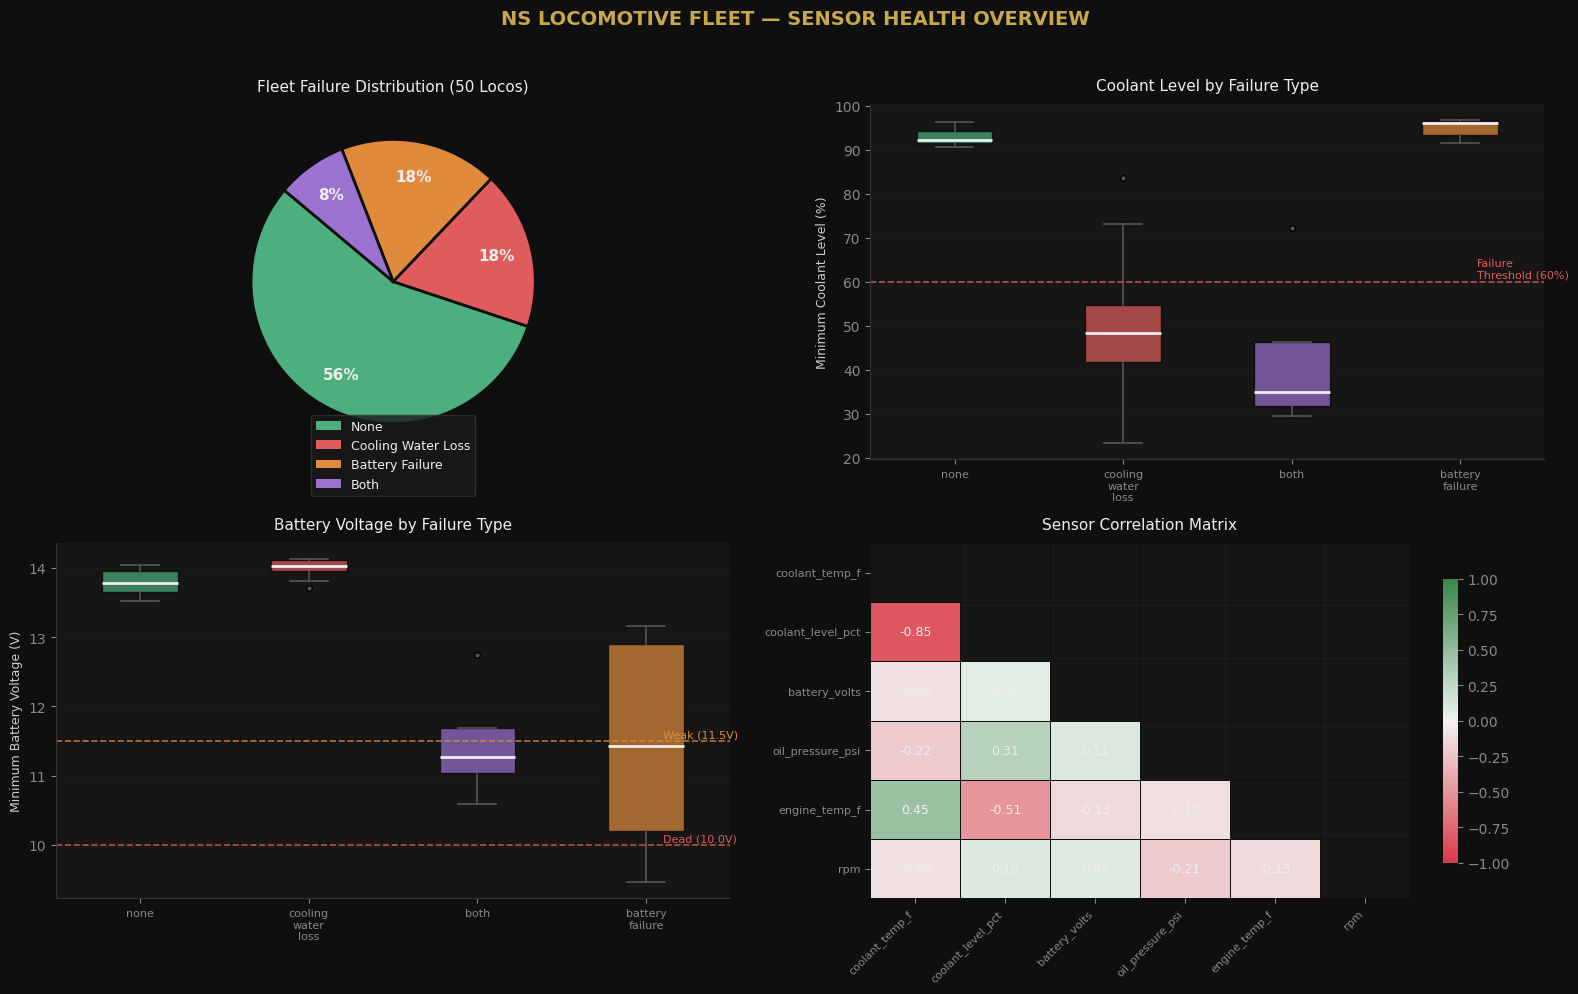

Correlation Matrix:
  coolant_level_pct    <-> coolant_temp_f        r = -0.85
  engine_temp_f        <-> coolant_level_pct     r = -0.51

Highly correlated sensors may be redundant features


In [47]:
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Plot styling
plt.rcParams.update({
    'figure.facecolor':  '#0F0F0F',
    'axes.facecolor':    '#161616',
    'axes.edgecolor':    '#333333',
    'axes.labelcolor':   '#CCCCCC',
    'axes.titlecolor':   '#EEEEEE',
    'xtick.color':       '#888888',
    'ytick.color':       '#888888',
    'grid.color':        '#252525',
    'text.color':        '#CCCCCC',
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

#Color palette
GOLD   = '#C8A84B'
RED    = '#E05C5C'
BLUE   = '#5B9BD5'
GREEN  = '#4CAF7D'
ORANGE = '#E08A3C'
PURPLE = '#9B72CF'
WHITE  = '#EEEEEE'
palette = {
    'none': GREEN,
    'cooling_water_loss': RED,
    'battery_failure': ORANGE,
    'both': PURPLE
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('NS LOCOMOTIVE FLEET — SENSOR HEALTH OVERVIEW',
             fontsize=14, fontweight='bold', color=GOLD, y=0.99)

# failure distribution pie chart
ax = axes[0, 0]
counts = fleet['failure_types'].value_counts()
colors = [palette[k] for k in counts.index]
wedges, texts, autotexts = ax.pie(
    counts, colors=colors, autopct='%1.0f%%', startangle=140,
    pctdistance=0.75, wedgeprops={'edgecolor': '#0F0F0F', 'linewidth': 2}
)
for at in autotexts:
    at.set_color(WHITE); at.set_fontsize(11); at.set_fontweight('bold')

legend_elements = [mpatches.Patch(facecolor=palette[k], label=k.replace('_',' ').title())
                   for k in counts.index]
ax.legend(handles=legend_elements, loc='lower center', fontsize=9,
          facecolor='#1A1A1A', edgecolor='#333', labelcolor=WHITE,
          bbox_to_anchor=(0.5, -0.12))
ax.set_title('Fleet Failure Distribution (50 Locos)', fontsize=11, color=WHITE, pad=10)

# boxplot: min coolant level by failure type
ax = axes[0, 1]
order = [o for o in ['none','cooling_water_loss','both','battery_failure']
         if o in fleet['failure_types'].unique()]
data = [fleet[fleet['failure_types']==ft]['min_coolant_level'].values for ft in order]
bp = ax.boxplot(data, patch_artist=True,
                medianprops={'color': WHITE, 'linewidth': 2},
                whiskerprops={'color': '#555', 'linewidth': 1.2},
                capprops={'color': '#555', 'linewidth': 1.2},
                flierprops={'marker':'o','markerfacecolor':'#555','markersize':4})
for patch, ft in zip(bp['boxes'], order):
    patch.set_facecolor(palette[ft]); patch.set_alpha(0.7)
ax.axhline(60, color=RED, linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(len(order)+0.1, 61, 'Failure\nThreshold (60%)', color=RED, fontsize=8)
ax.set_xticks(range(1, len(order)+1))
ax.set_xticklabels([o.replace('_','\n') for o in order], fontsize=8)
ax.set_ylabel('Minimum Coolant Level (%)', fontsize=9)
ax.set_title('Coolant Level by Failure Type', fontsize=11, color=WHITE, pad=10)
ax.grid(axis='y', alpha=0.4)

# Boxplot: min battery voltage by failure type 
ax = axes[1, 0]
data_bat = [fleet[fleet['failure_types']==ft]['min_battery_volts'].values for ft in order]
bp2 = ax.boxplot(data_bat, patch_artist=True,
                 medianprops={'color': WHITE, 'linewidth': 2},
                 whiskerprops={'color': '#555', 'linewidth': 1.2},
                 capprops={'color': '#555', 'linewidth': 1.2},
                 flierprops={'marker':'o','markerfacecolor':'#555','markersize':4})
for patch, ft in zip(bp2['boxes'], order):
    patch.set_facecolor(palette[ft]); patch.set_alpha(0.7)
ax.axhline(11.5, color=ORANGE, linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(len(order)+0.1, 11.55, 'Weak (11.5V)', color=ORANGE, fontsize=8)
ax.axhline(10.0, color=RED, linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(len(order)+0.1, 10.05, 'Dead (10.0V)', color=RED, fontsize=8)
ax.set_xticks(range(1, len(order)+1))
ax.set_xticklabels([o.replace('_','\n') for o in order], fontsize=8)
ax.set_ylabel('Minimum Battery Voltage (V)', fontsize=9)
ax.set_title('Battery Voltage by Failure Type', fontsize=11, color=WHITE, pad=10)
ax.grid(axis='y', alpha=0.4)

#Heatmap: sensor correlations
ax = axes[1, 1]
sensor_cols = ['coolant_temp_f','coolant_level_pct','battery_volts',
               'oil_pressure_psi','engine_temp_f','rpm']
corr = df[sensor_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(10,133,as_cmap=True),
            vmax=1, vmin=-1, center=0, annot=True, fmt='.2f',
            annot_kws={'size':9,'color':WHITE},
            linewidths=0.5, linecolor='#0F0F0F',
            cbar_kws={'shrink':0.8}, ax=ax)
ax.set_xticklabels([s for s in sensor_cols], fontsize=8, rotation=45, ha='right')
ax.set_yticklabels([s for s in sensor_cols], fontsize=8, rotation=0)
ax.set_title('Sensor Correlation Matrix', fontsize=11, color=WHITE, pad=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# KEY INSIGHT
print('Correlation Matrix:')
high_corr = [(sensor_cols[i], sensor_cols[j], round(corr.iloc[i,j],2))
             for i in range(len(sensor_cols))
             for j in range(i)
             if abs(corr.iloc[i,j]) > 0.5]
for a, b, v in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f'  {a:20s} <-> {b:20s}  r = {v}')
print('\nHighly correlated sensors may be redundant features')

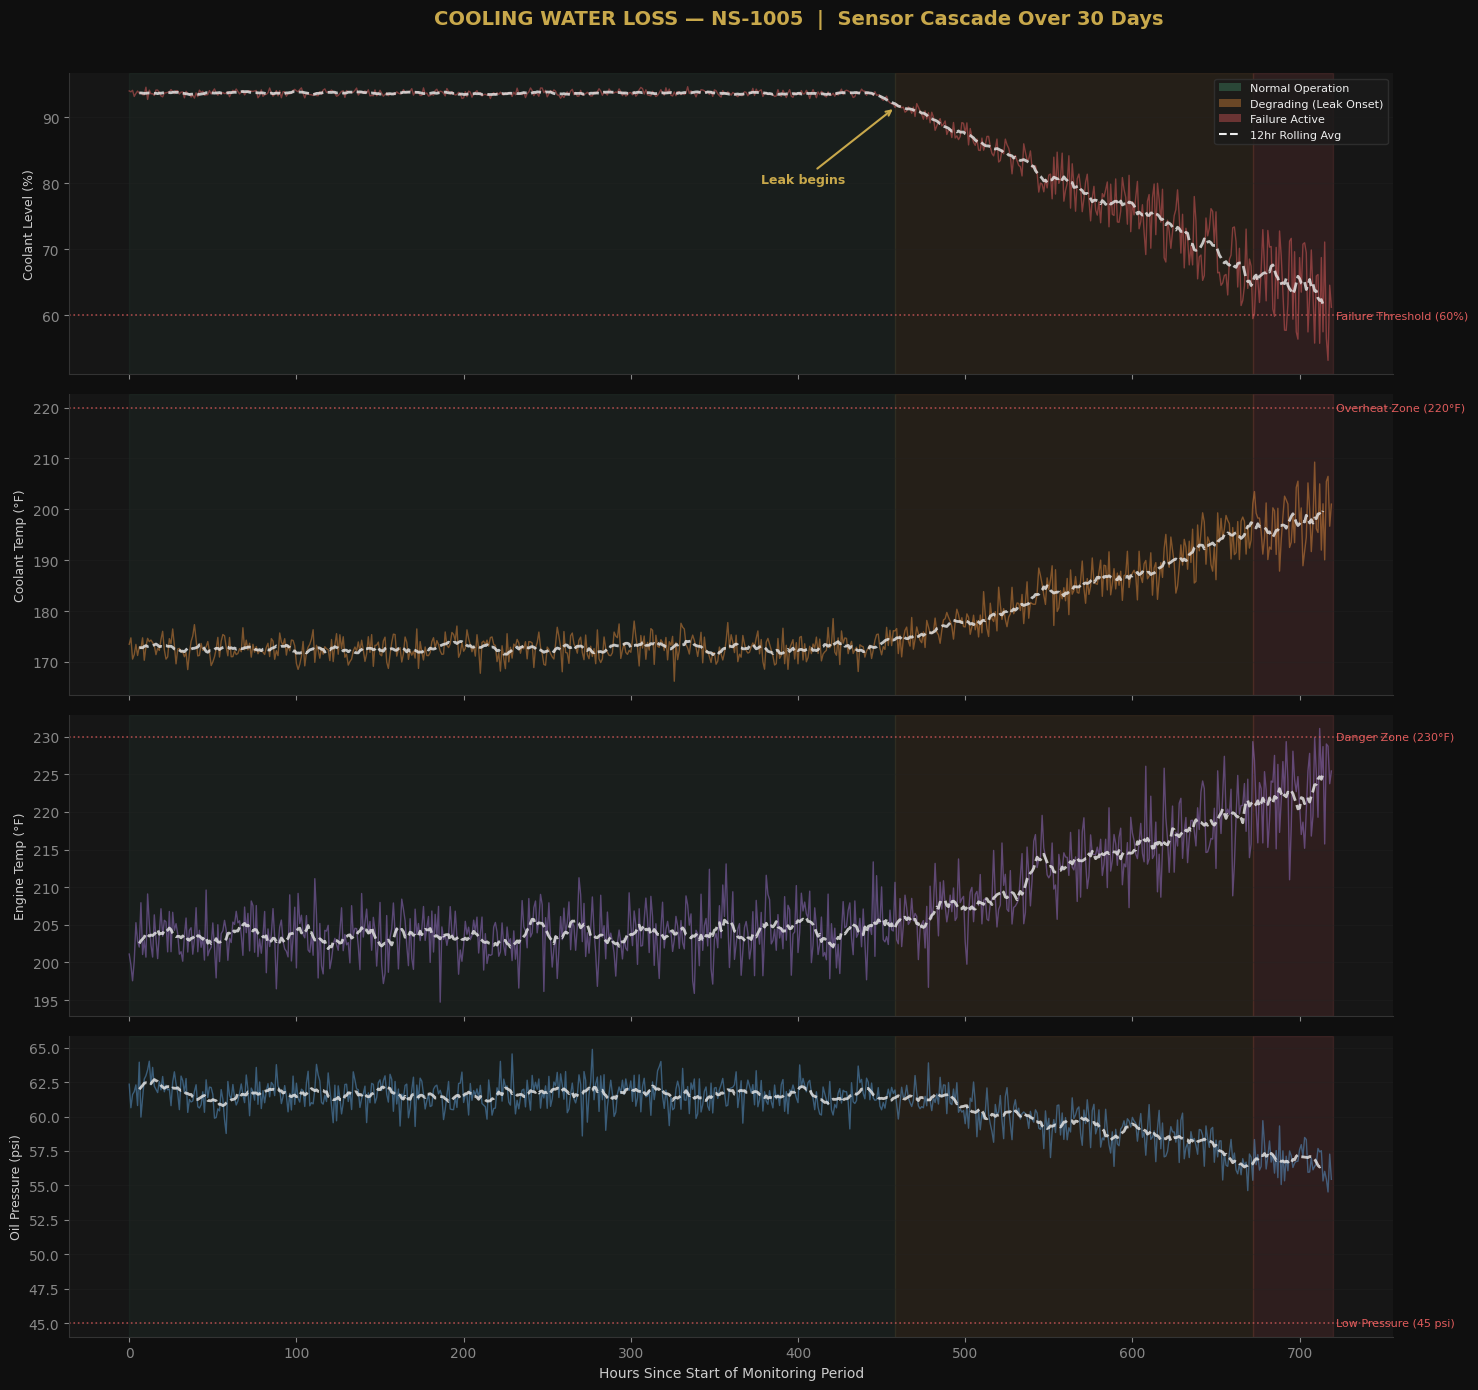

NS-1005 leak onset at hour : 458
NS-1005 failure label fires at hour: 672
Gap between onset and failure: 214 hours

KEY INSIGHT: That gap is the prediction window.
A model trained on the degrading zone can warn NS before the failure label ever fires.


In [42]:
#COOLING WATER LOSS DEGRADATION 
from matplotlib.lines import Line2D

loco_cw = df[df['locomotive_id'] == 'NS-1005'].copy()
failure_start = loco_cw[loco_cw['coolant_level_pct'] < 92]['hour'].min()
failure_zone  = loco_cw[loco_cw['cooling_water_loss'] == 1]['hour'].min()

sensors_cw = [
    ('coolant_level_pct', 'Coolant Level (%)',  RED,    60,  'Failure Threshold (60%)'),
    ('coolant_temp_f',    'Coolant Temp (°F)',  ORANGE, 220, 'Overheat Zone (220°F)'),
    ('engine_temp_f',     'Engine Temp (°F)',   PURPLE, 230, 'Danger Zone (230°F)'),
    ('oil_pressure_psi',  'Oil Pressure (psi)', BLUE,   45,  'Low Pressure (45 psi)'),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('COOLING WATER LOSS — NS-1005  |  Sensor Cascade Over 30 Days',
             fontsize=14, fontweight='bold', color=GOLD, y=0.99)

for i, (col, label, color, threshold, thresh_label) in enumerate(sensors_cw):
    ax = axes[i]

    # Zone shading
    ax.axvspan(0, failure_start, alpha=0.06, color=GREEN)
    ax.axvspan(failure_start, failure_zone, alpha=0.08, color=ORANGE)
    ax.axvspan(failure_zone, 720, alpha=0.12, color=RED)

    # Raw sensor + smoothed trend
    ax.plot(loco_cw['hour'], loco_cw[col], color=color, linewidth=1.0, alpha=0.5)
    ax.plot(loco_cw['hour'], loco_cw[col].rolling(12, center=True).mean(),
            color=WHITE, linewidth=2.0, alpha=0.8, linestyle='--')

    # Threshold line
    ax.axhline(threshold, color=RED, linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(722, threshold, thresh_label, color=RED, fontsize=8, va='center')

    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    if i == 0:
        legend_elements = [
            mpatches.Patch(facecolor=GREEN,  alpha=0.3, label='Normal Operation'),
            mpatches.Patch(facecolor=ORANGE, alpha=0.4, label='Degrading (Leak Onset)'),
            mpatches.Patch(facecolor=RED,    alpha=0.4, label='Failure Active'),
            Line2D([0],[0], color=WHITE, linestyle='--', linewidth=1.5, label='12hr Rolling Avg'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8,
                  facecolor='#1A1A1A', edgecolor='#333', labelcolor=WHITE)
        ax.annotate('Leak begins',
                    xy=(failure_start, loco_cw.loc[loco_cw['hour']==failure_start,'coolant_level_pct'].values[0]),
                    xytext=(failure_start - 80, 80),
                    arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5),
                    color=GOLD, fontsize=9, fontweight='bold')

axes[-1].set_xlabel('Hours Since Start of Monitoring Period', fontsize=10)
plt.tight_layout(rect=[0, 0, 0.93, 0.98])
plt.show()

print(f'NS-1005 leak onset at hour : {failure_start}')
print(f'NS-1005 failure label fires at hour: {failure_zone}')
print(f'Gap between onset and failure: {failure_zone - failure_start} hours')
print('\nKEY INSIGHT: That gap is the prediction window.')
print('A model trained on the degrading zone can warn NS before the failure label ever fires.')


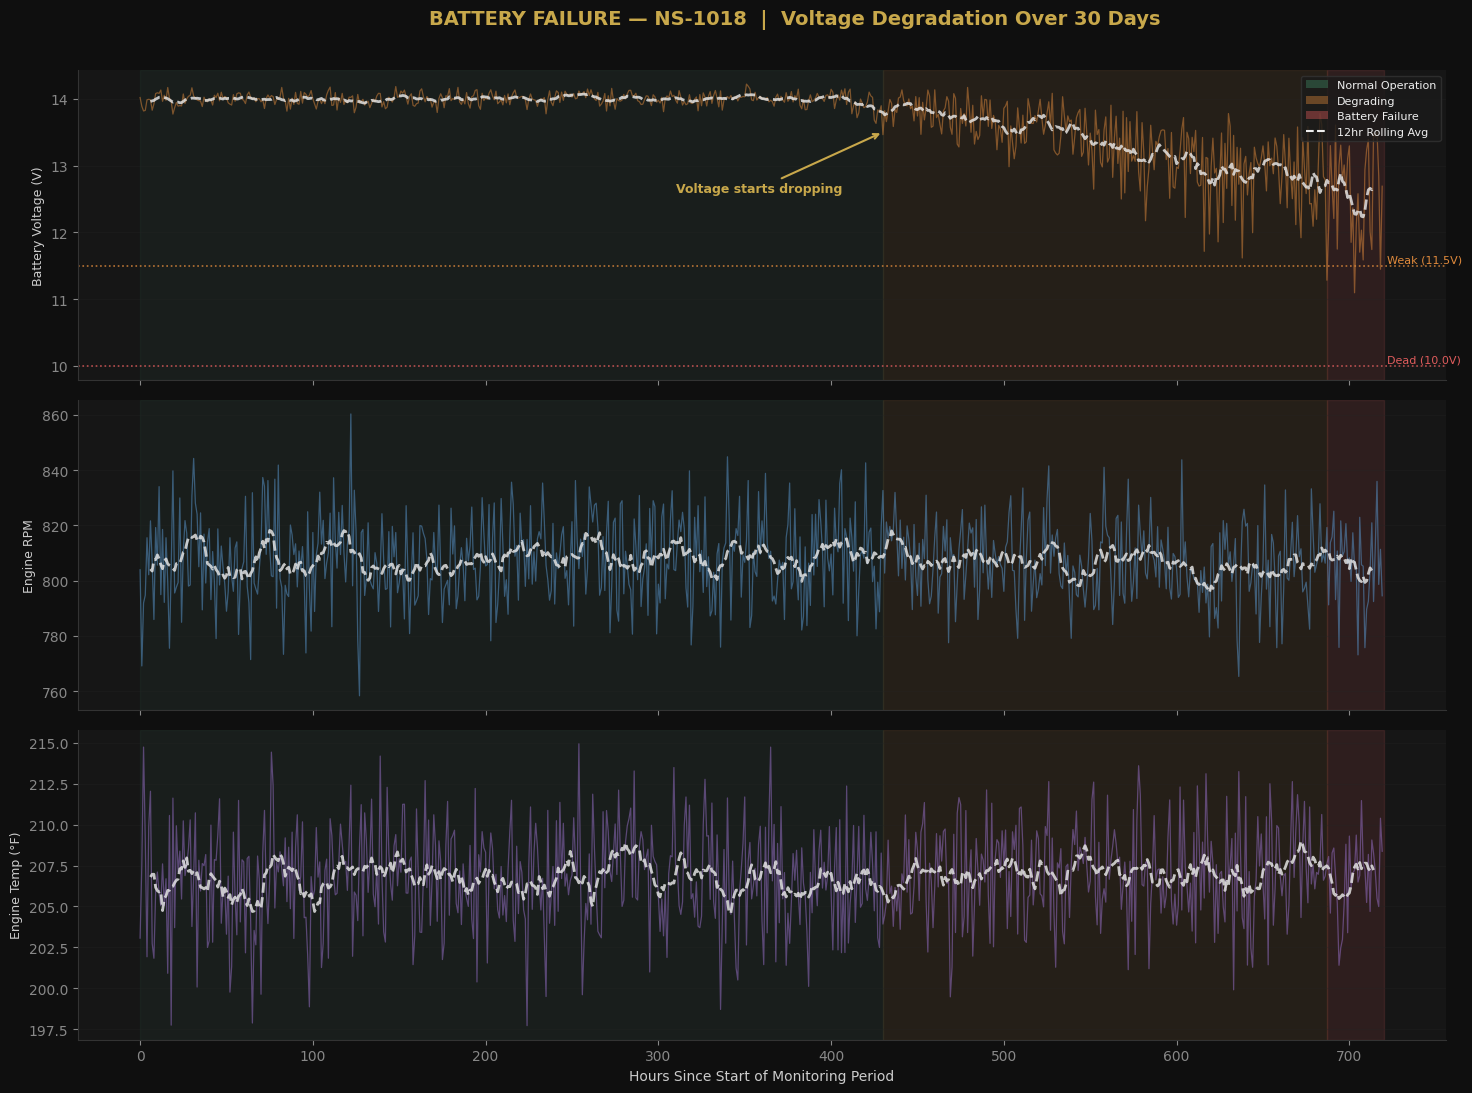

NS-1018 voltage degradation starts at hour: 430
NS-1018 failure label fires at hour       : 687
Prediction window                         : 257 hours


In [43]:
# BATTERY FAILURE DEGRADATION 
loco_bat = df[df['locomotive_id'] == 'NS-1018'].copy()
bat_degrade = loco_bat[loco_bat['battery_volts'] < 13.5]['hour'].min()
bat_failure = loco_bat[loco_bat['battery_failure'] == 1]['hour'].min()

sensors_bat = [
    ('battery_volts', 'Battery Voltage (V)', ORANGE),
    ('rpm',           'Engine RPM',          BLUE),
    ('engine_temp_f', 'Engine Temp (°F)',     PURPLE),
]

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle('BATTERY FAILURE — NS-1018  |  Voltage Degradation Over 30 Days',
             fontsize=14, fontweight='bold', color=GOLD, y=0.99)

for i, (col, label, color) in enumerate(sensors_bat):
    ax = axes[i]

    if pd.notna(bat_degrade):
        ax.axvspan(0, bat_degrade, alpha=0.06, color=GREEN)
        ax.axvspan(bat_degrade, bat_failure if pd.notna(bat_failure) else 720, alpha=0.08, color=ORANGE)
    if pd.notna(bat_failure):
        ax.axvspan(bat_failure, 720, alpha=0.12, color=RED)

    ax.plot(loco_bat['hour'], loco_bat[col], color=color, linewidth=0.9, alpha=0.5)
    ax.plot(loco_bat['hour'], loco_bat[col].rolling(12, center=True).mean(),
            color=WHITE, linewidth=2.0, alpha=0.8, linestyle='--')

    if col == 'battery_volts':
        ax.axhline(11.5, color=ORANGE, linestyle=':', linewidth=1.2, alpha=0.8)
        ax.text(722, 11.55, 'Weak (11.5V)',  color=ORANGE, fontsize=8)
        ax.axhline(10.0, color=RED,    linestyle=':', linewidth=1.2, alpha=0.8)
        ax.text(722, 10.05, 'Dead (10.0V)', color=RED,    fontsize=8)
        if pd.notna(bat_degrade):
            ax.annotate('Voltage starts dropping',
                        xy=(bat_degrade, 13.5),
                        xytext=(bat_degrade - 120, 12.6),
                        arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5),
                        color=GOLD, fontsize=9, fontweight='bold')
        legend_elements = [
            mpatches.Patch(facecolor=GREEN,  alpha=0.3, label='Normal Operation'),
            mpatches.Patch(facecolor=ORANGE, alpha=0.4, label='Degrading'),
            mpatches.Patch(facecolor=RED,    alpha=0.4, label='Battery Failure'),
            Line2D([0],[0], color=WHITE, linestyle='--', linewidth=1.5, label='12hr Rolling Avg'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8,
                  facecolor='#1A1A1A', edgecolor='#333', labelcolor=WHITE)

    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('Hours Since Start of Monitoring Period', fontsize=10)
plt.tight_layout(rect=[0, 0, 0.93, 0.98])
plt.show()

print(f'NS-1018 voltage degradation starts at hour: {bat_degrade}')
print(f'NS-1018 failure label fires at hour       : {bat_failure}')
if pd.notna(bat_degrade) and pd.notna(bat_failure):
    print(f'Prediction window                         : {int(bat_failure - bat_degrade)} hours')

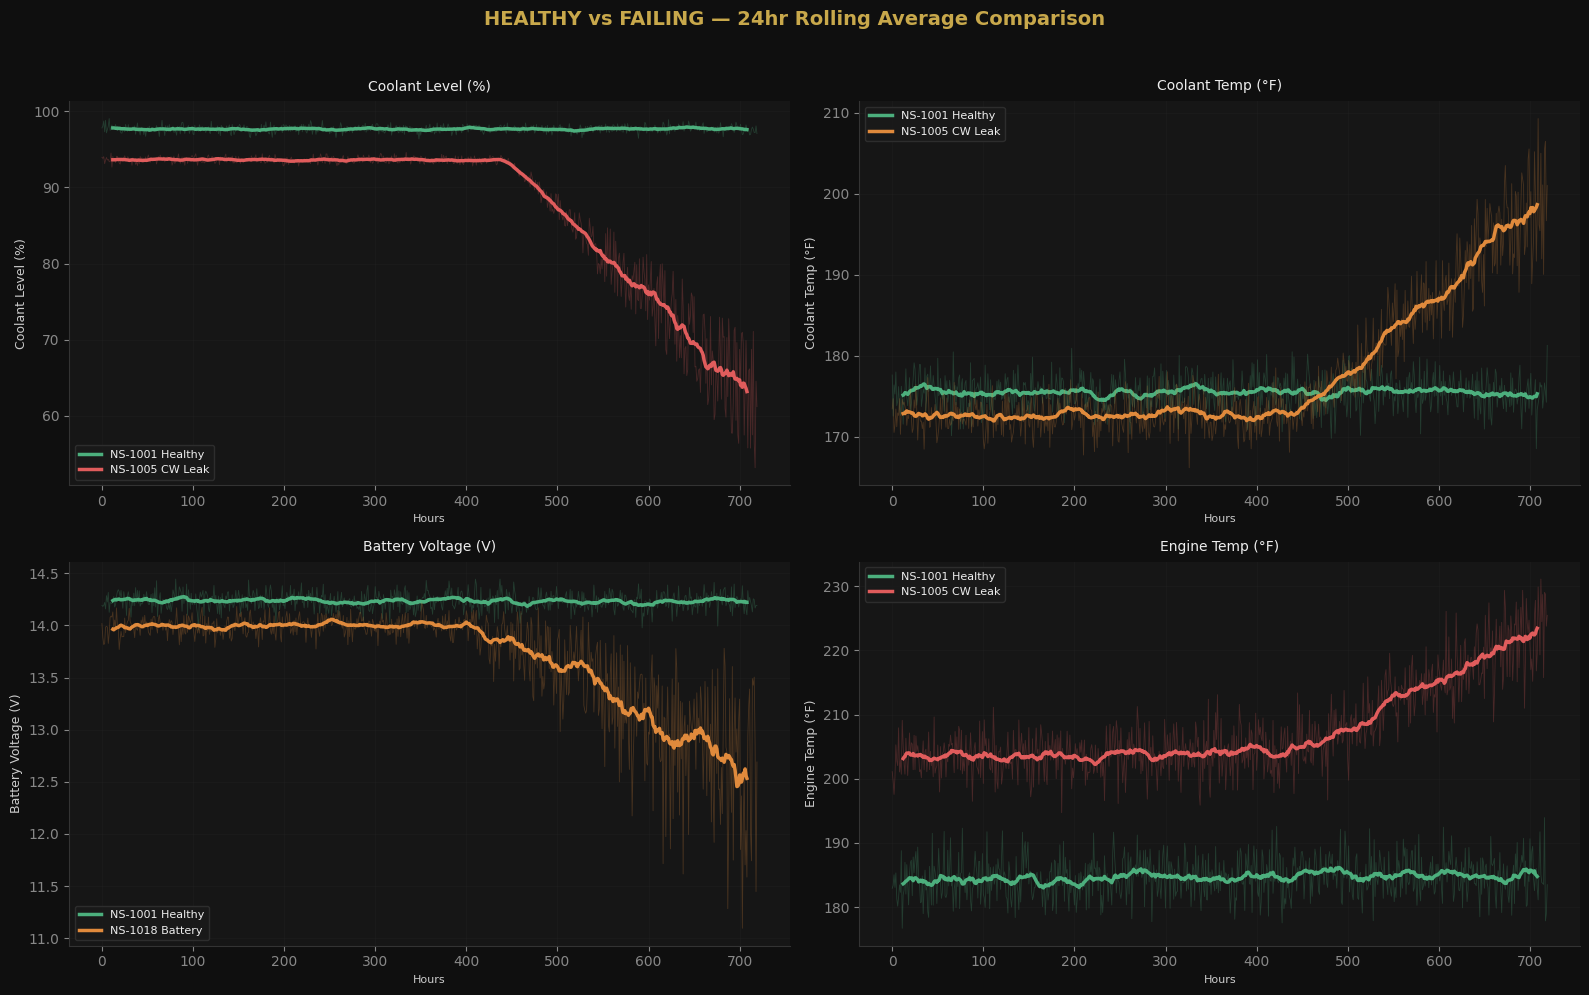

KEY INSIGHT: The healthy locomotive (green) is flat across all 4 sensors.
The failing locomotives drift away from that baseline in a consistent direction.


In [45]:
#HEALTHY vs FAILING SIDE-BY-SIDE 
healthy    = df[df['locomotive_id'] == 'NS-1001']
failing_cw = df[df['locomotive_id'] == 'NS-1005']
failing_bat= df[df['locomotive_id'] == 'NS-1018']

comparisons = [
    ('coolant_level_pct', 'Coolant Level (%)',
     [(healthy, GREEN, 'NS-1001 Healthy'), (failing_cw,  RED,    'NS-1005 CW Leak')]),
    ('coolant_temp_f',    'Coolant Temp (°F)',
     [(healthy, GREEN, 'NS-1001 Healthy'), (failing_cw,  ORANGE, 'NS-1005 CW Leak')]),
    ('battery_volts',     'Battery Voltage (V)',
     [(healthy, GREEN, 'NS-1001 Healthy'), (failing_bat, ORANGE, 'NS-1018 Battery')]),
    ('engine_temp_f',     'Engine Temp (°F)',
     [(healthy, GREEN, 'NS-1001 Healthy'), (failing_cw,  RED,    'NS-1005 CW Leak')]),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('HEALTHY vs FAILING — 24hr Rolling Average Comparison',
             fontsize=14, fontweight='bold', color=GOLD, y=0.99)

for i, (col, label, locos) in enumerate(comparisons):
    ax = axes[i//2][i%2]
    for loco_df, color, loco_label in locos:
        # Raw signal faint, trend bold
        ax.plot(loco_df['hour'], loco_df[col],
                color=color, linewidth=0.6, alpha=0.25)
        ax.plot(loco_df['hour'], loco_df[col].rolling(24, center=True).mean(),
                color=color, linewidth=2.5, label=loco_label)
    ax.set_ylabel(label, fontsize=9)
    ax.set_xlabel('Hours', fontsize=8)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, facecolor='#1A1A1A', edgecolor='#333', labelcolor=WHITE)
    ax.set_title(label, fontsize=10, color=WHITE, pad=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print('KEY INSIGHT: The healthy locomotive (green) is flat across all 4 sensors.')
print('The failing locomotives drift away from that baseline in a consistent direction.')


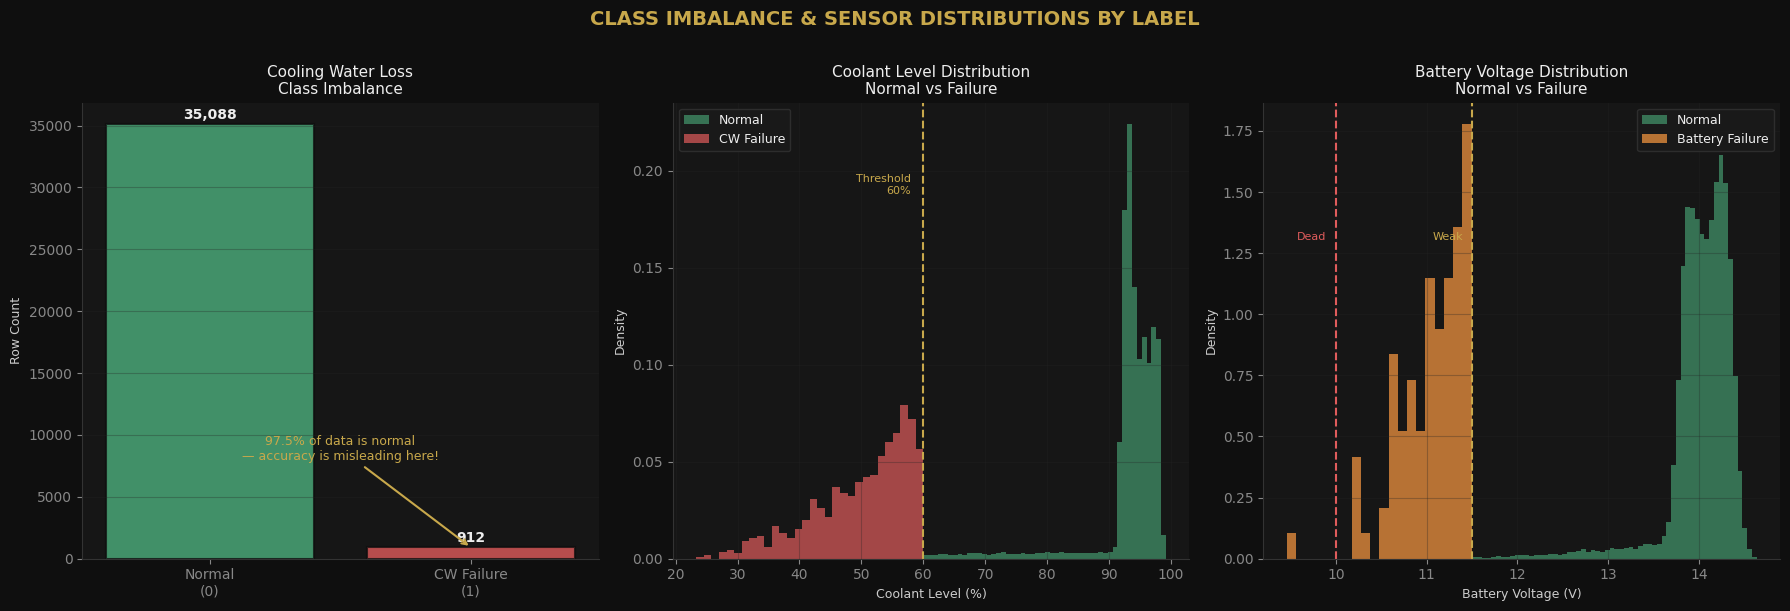

KEY INSIGHT — Coolant level:
  Normal distribution clusters tightly above 90%
  Failure distribution sits below 60% — clean separation = strong feature

KEY INSIGHT — Battery voltage:
  Normal distribution peaks around 13.8-14.4V
  Failure distribution spreads from 8-12V — more overlap = harder problem
  We will need rolling features to capture the drift, not just the raw value


In [ ]:
#CLASS IMBALANCE + DISTRIBUTIONS 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('CLASS IMBALANCE & SENSOR DISTRIBUTIONS BY LABEL',
             fontsize=14, fontweight='bold', color=GOLD, y=1.01)

# Class imbalance bar
ax = axes[0]
cw_val = df['cooling_water_loss'].value_counts().sort_index()
bars = ax.bar(['Normal\n(0)', 'CW Failure\n(1)'],
              [cw_val[0], cw_val[1]], color=[GREEN, RED], alpha=0.8,
              edgecolor='#0F0F0F', linewidth=1.5)
for bar, count in zip(bars, [cw_val[0], cw_val[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}', ha='center', va='bottom', color=WHITE,
            fontsize=10, fontweight='bold')
ax.annotate('97.5% of data is normal\n— accuracy is misleading here!',
            xy=(1, cw_val[1]), xytext=(0.5, 8000),
            arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5),
            color=GOLD, fontsize=9, ha='center')
ax.set_title('Cooling Water Loss\nClass Imbalance', fontsize=11, color=WHITE)
ax.set_ylabel('Row Count', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Coolant level distribution
ax = axes[1]
ax.hist(df[df['cooling_water_loss']==0]['coolant_level_pct'],
        bins=50, color=GREEN, alpha=0.6, label='Normal', density=True)
ax.hist(df[df['cooling_water_loss']==1]['coolant_level_pct'],
        bins=30, color=RED,   alpha=0.7, label='CW Failure', density=True)
ax.axvline(60, color=GOLD, linestyle='--', linewidth=1.5)
ax.text(58, ax.get_ylim()[1]*0.8, 'Threshold\n60%', color=GOLD, fontsize=8, ha='right')
ax.set_xlabel('Coolant Level (%)', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.set_title('Coolant Level Distribution\nNormal vs Failure', fontsize=11, color=WHITE)
ax.legend(fontsize=9, facecolor='#1A1A1A', edgecolor='#333', labelcolor=WHITE)
ax.grid(alpha=0.3)

# Battery voltage distribution
ax = axes[2]
ax.hist(df[df['battery_failure']==0]['battery_volts'],
        bins=60, color=GREEN,  alpha=0.6, label='Normal', density=True)
ax.hist(df[df['battery_failure']==1]['battery_volts'],
        bins=20, color=ORANGE, alpha=0.8, label='Battery Failure', density=True)
ax.axvline(11.5, color=GOLD, linestyle='--', linewidth=1.5)
ax.axvline(10.0, color=RED,  linestyle='--', linewidth=1.5)
ax.text(11.4, ax.get_ylim()[1]*0.7, 'Weak', color=GOLD, fontsize=8, ha='right')
ax.text(9.9,  ax.get_ylim()[1]*0.7, 'Dead', color=RED,  fontsize=8, ha='right')
ax.set_xlabel('Battery Voltage (V)', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.set_title('Battery Voltage Distribution\nNormal vs Failure', fontsize=11, color=WHITE)
ax.legend(fontsize=9, facecolor='#1A1A1A', edgecolor='#333', labelcolor=WHITE)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
    
print('KEY INSIGHT — Coolant level:')
print('  Normal distribution clusters tightly above 90%')
print('  Failure distribution sits below 60% — clean separation = strong feature')
print()
print('KEY INSIGHT — Battery voltage:')
print('  Normal distribution peaks around 13.8-14.4V')
print('  Failure distribution spreads from 8-12V — more overlap = harder problem')


*Feature Engineering*

In [55]:
#ROLLING WINDOW FEATURE ENGINEERING
df = df.sort_values(['locomotive_id', 'timestamp']).reset_index(drop=True)

# Sensors we'll engineer rolling features for
sensor_cols = [
    'coolant_temp_f',
    'coolant_level_pct',
    'battery_volts',
    'oil_pressure_psi',
    'engine_temp_f',
    'rpm',
]

WINDOW = 24   # hours to look back
LAG = 6    # hours back for rate-of-change

# Apply rolling features grouped by locomotive
# CRITICAL: groupby().transform() keeps the same index alignment
# min_periods=1 means we don't lose the first 24 rows per locomotive
for col in sensor_cols:
    grp = df.groupby('locomotive_id')[col]

    df[f'{col}_mean24'] = grp.transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
    df[f'{col}_std24'] = grp.transform(lambda x: x.rolling(WINDOW, min_periods=1).std().fillna(0))
    df[f'{col}_min24'] = grp.transform(lambda x: x.rolling(WINDOW, min_periods=1).min())
    df[f'{col}_max24'] = grp.transform(lambda x: x.rolling(WINDOW, min_periods=1).max())
    df[f'{col}_roc6'] = grp.transform(lambda x: x.diff(LAG).fillna(0))  # rate of change

#Count new feature columns
new_features = [c for c in df.columns if any(
    c.endswith(s) for s in ['_mean24','_std24','_min24','_max24','_roc6']
)]

print(f'Original sensor columns   : {len(sensor_cols)}')
print(f'New engineered features   : {len(new_features)}')
print(f'Total feature columns now : {len(sensor_cols) + len(new_features)}')
print()
print('Sample engineered features for NS-1005 (a failing locomotive):')
sample_cols = ['hour','coolant_level_pct','coolant_level_pct_mean24',
               'coolant_level_pct_std24','coolant_level_pct_roc6']
print(df[df['locomotive_id']=='NS-1005'][sample_cols].iloc[550:570].to_string(index=False))
print()

Original sensor columns   : 6
New engineered features   : 30
Total feature columns now : 36

Sample engineered features for NS-1005 (a failing locomotive):
 hour  coolant_level_pct  coolant_level_pct_mean24  coolant_level_pct_std24  coolant_level_pct_roc6
  550              81.22                 82.216667                 2.015010                    2.58
  551              81.37                 82.102500                 1.980398                    1.36
  552              77.62                 81.945000                 2.179044                   -2.23
  553              83.93                 81.943333                 2.177443                    5.25
  554              78.34                 81.700833                 2.242940                   -2.28
  555              84.69                 81.755000                 2.300467                    5.42
  556              79.96                 81.641667                 2.319834                   -1.26
  557              80.57                 81.

In [49]:
df.head()

,timestamp,locomotive_id,failure_type_true,coolant_temp_f,coolant_level_pct,battery_volts,oil_pressure_psi,engine_temp_f,rpm,ambient_temp_f,...,engine_temp_f_mean24,engine_temp_f_std24,engine_temp_f_min24,engine_temp_f_max24,engine_temp_f_roc6,rpm_mean24,rpm_std24,rpm_min24,rpm_max24,rpm_roc6
0,2026-01-01 00:00:00,NS-1001,none,177.64,97.82,14.193,63.45,182.94,801.7,59.75,...,182.940000,0.000000,182.94,182.94,0.0,801.70,0.000000,801.7,801.7,0.0
1,2026-01-01 01:00:00,NS-1001,none,172.57,98.03,14.183,63.24,183.40,783.5,58.00,...,183.170000,0.325269,182.94,183.40,0.0,792.60,12.869343,783.5,801.7,0.0
2,2026-01-01 02:00:00,NS-1001,none,176.41,98.73,14.191,63.46,185.05,829.8,51.85,...,183.796667,1.109519,182.94,185.05,0.0,805.00,23.325737,783.5,829.8,0.0
3,2026-01-01 03:00:00,NS-1001,none,175.29,97.30,14.221,63.97,183.08,821.4,60.50,...,183.617500,0.974213,182.94,185.05,0.0,809.10,20.735638,783.5,829.8,0.0
4,2026-01-01 04:00:00,NS-1001,none,178.01,98.82,14.158,64.86,185.34,791.9,52.37,...,183.962000,1.142462,182.94,185.34,0.0,805.66,19.535685,783.5,829.8,0.0


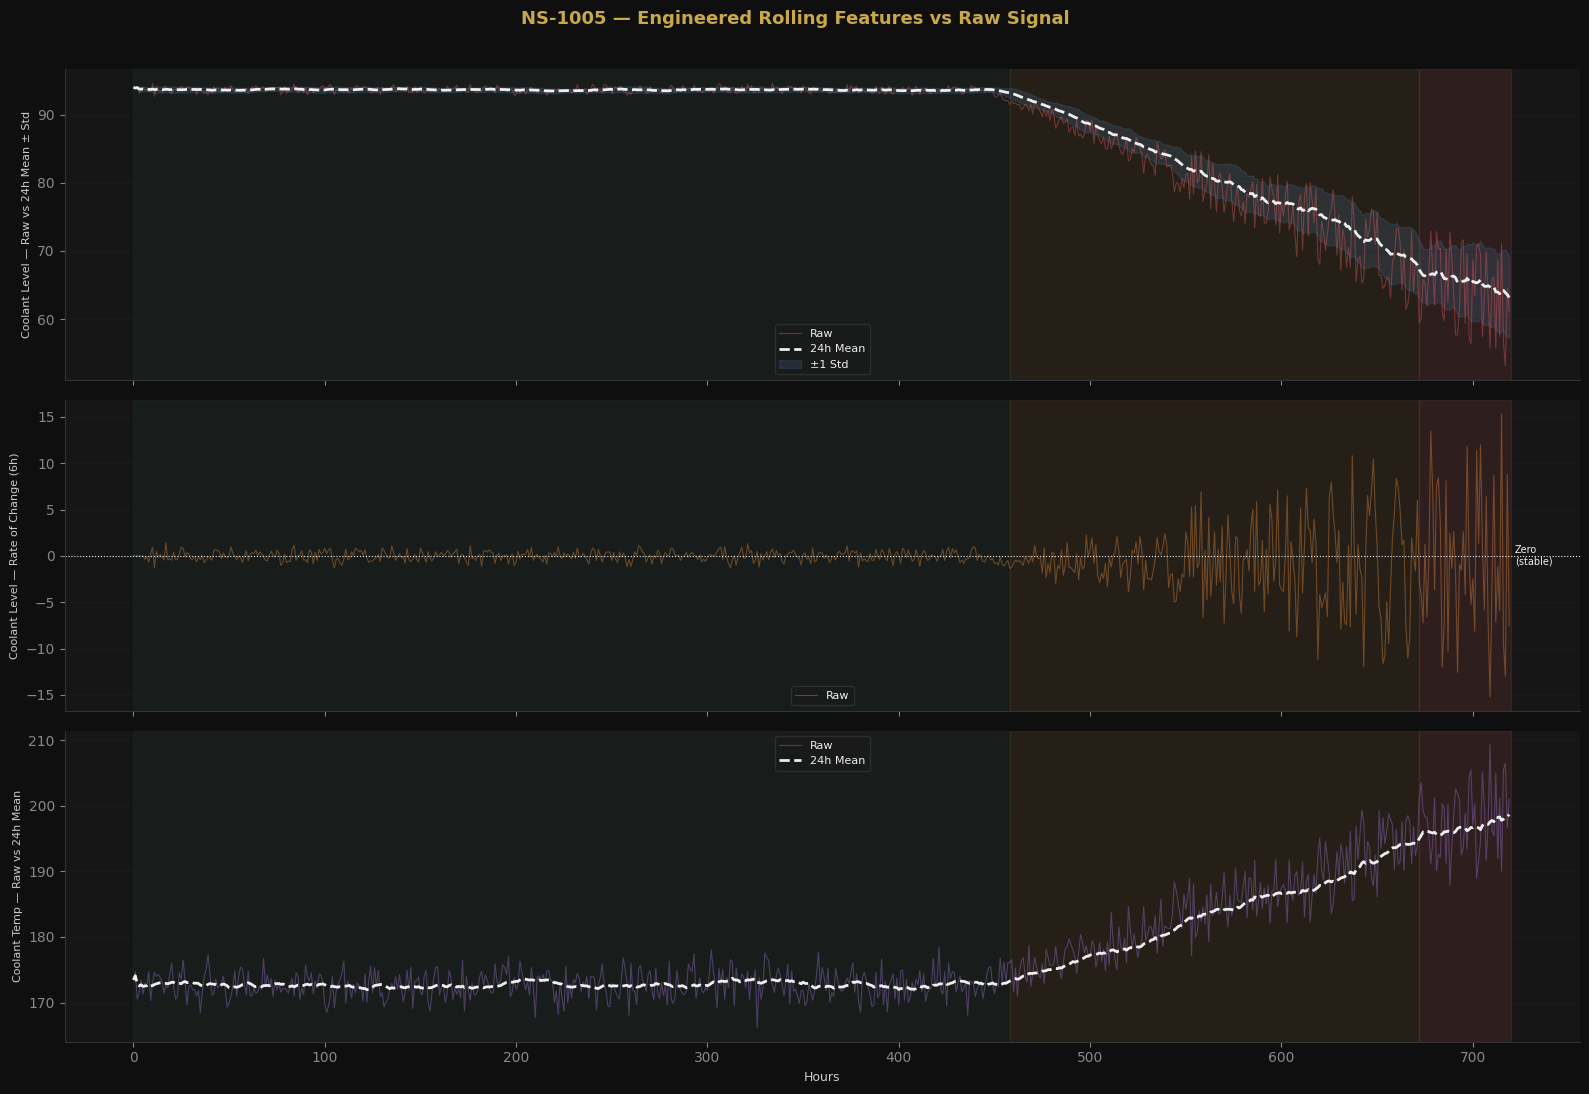

In [57]:
#VISUALIZE ROLLING FEATURES ON NS-1005
# Show how the engineered features look on the failing locomotive
loco = df[df['locomotive_id'] == 'NS-1005'].copy()
failure_hour = loco[loco['cooling_water_loss']==1]['hour'].min()
onset_hour   = 458   # from our EDA

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle('NS-1005 — Engineered Rolling Features vs Raw Signal',
             fontsize=13, fontweight='bold', color=GOLD, y=0.99)

plots = [
    ('coolant_level_pct', 'coolant_level_pct_mean24', 'coolant_level_pct_std24',
     'Coolant Level — Raw vs 24h Mean ± Std', RED, BLUE),
    ('coolant_level_pct_roc6', None, None,
     'Coolant Level — Rate of Change (6h)', ORANGE, None),
    ('coolant_temp_f', 'coolant_temp_f_mean24', None,
     'Coolant Temp — Raw vs 24h Mean', PURPLE, None),
]

for i, (raw_col, mean_col, std_col, title, color, color2) in enumerate(plots):
    ax = axes[i]
    ax.axvspan(0, onset_hour, alpha=0.05, color=GREEN)
    ax.axvspan(onset_hour, failure_hour, alpha=0.08, color=ORANGE)
    ax.axvspan(failure_hour, 720, alpha=0.12, color=RED)

    # Raw signal
    ax.plot(loco['hour'], loco[raw_col], color=color,
            linewidth=0.8, alpha=0.4, label='Raw')

    # Rolling mean
    if mean_col:
        ax.plot(loco['hour'], loco[mean_col], color=WHITE,
                linewidth=2.0, linestyle='--', label='24h Mean')

    # Rolling std band
    if std_col and mean_col:
        ax.fill_between(loco['hour'],
                        loco[mean_col] - loco[std_col],
                        loco[mean_col] + loco[std_col],
                        color=color2, alpha=0.15, label='±1 Std')

    # Zero line for rate-of-change
    if 'roc6' in raw_col:
        ax.axhline(0, color=WHITE, linewidth=0.8, linestyle=':')
        ax.text(722, 0, 'Zero\n(stable)', color=WHITE, fontsize=7, va='center')

    ax.set_ylabel(title, fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8, facecolor='#1A1A1A', edgecolor='#333', labelcolor=WHITE)

axes[-1].set_xlabel('Hours', fontsize=9)
plt.tight_layout(rect=[0,0,1,0.98])
plt.show()


In [59]:
#TEMPORAL TRAIN / TEST SPLIT ───────────────────────────────
# Use first 75% of hours (0-539) for training, last 25% (540-719) for testing
# This respects the time ordering — no future data leaks into training

SPLIT_HOUR = 540   

# Define our feature columns
# Raw sensors + all engineered rolling features
# Exclude: timestamp, locomotive_id, failure_type_true (ground truth), labels, hour
feature_cols = sensor_cols + new_features

train_df = df[df['hour'] <  SPLIT_HOUR].copy()
test_df  = df[df['hour'] >= SPLIT_HOUR].copy()

X_train_cw = train_df[feature_cols]
X_test_cw  = test_df[feature_cols]
y_train_cw = train_df['cooling_water_loss']
y_test_cw  = test_df['cooling_water_loss']

X_train_bat = train_df[feature_cols]
X_test_bat  = test_df[feature_cols]
y_train_bat = train_df['battery_failure']
y_test_bat  = test_df['battery_failure']

print('TRAIN / TEST SPLIT')
print(f'Training hours  : 0 – {SPLIT_HOUR-1}   ({train_df.shape[0]:,} rows)')
print(f'Testing hours   : {SPLIT_HOUR} – 719  ({test_df.shape[0]:,} rows)')
print(f'Feature columns : {len(feature_cols)}')
print()
print('Cooling Water Loss label distribution:')
print(f'  Train — failure rows: {y_train_cw.sum():,}  ({y_train_cw.mean()*100:.1f}%)')
print(f'  Test  — failure rows: {y_test_cw.sum():,}   ({y_test_cw.mean()*100:.1f}%)')
print()
print('Battery Failure label distribution:')
print(f'  Train — failure rows: {y_train_bat.sum():,}   ({y_train_bat.mean()*100:.2f}%)')
print(f'  Test  — failure rows: {y_test_bat.sum():,}    ({y_test_bat.mean()*100:.2f}%)')


TRAIN / TEST SPLIT
Training hours  : 0 – 539   (27,000 rows)
Testing hours   : 540 – 719  (9,000 rows)
Feature columns : 36

Cooling Water Loss label distribution:
  Train — failure rows: 74  (0.3%)
  Test  — failure rows: 838   (9.3%)

Battery Failure label distribution:
  Train — failure rows: 2   (0.01%)
  Test  — failure rows: 92    (1.02%)


*Feature Scaling*

In [60]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cw)
X_test_scaled  = scaler.transform(X_test_cw)

#convert back to dataframe for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

print('Before scaling — first 3 features, sample values:')
print(X_train_cw[feature_cols[:3]].describe().round(2).loc[['mean','std','min','max']])
print()
print('After scaling — same 3 features:')
print(X_train_scaled[feature_cols[:3]].describe().round(2).loc[['mean','std','min','max']])
print()

Before scaling — first 3 features, sample values:
      coolant_temp_f  coolant_level_pct  battery_volts
mean          178.08              93.68          14.07
std             5.92               4.96           0.25
min           163.37              47.11          11.27
max           217.98              99.18          14.64

After scaling — same 3 features:
      coolant_temp_f  coolant_level_pct  battery_volts
mean            0.00              -0.00          -0.00
std             1.00               1.00           1.00
min            -2.49              -9.39         -11.12
max             6.74               1.11           2.25



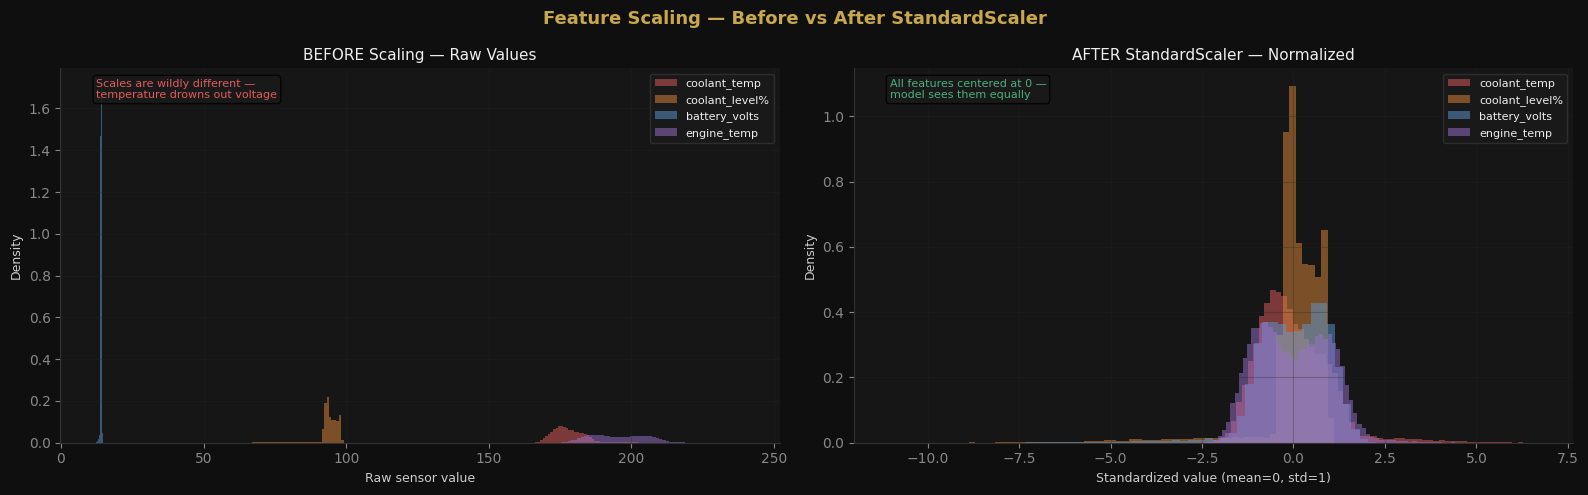

In [61]:
#VISUALIZE: BEFORE vs AFTER SCALING

show_features = ['coolant_temp_f', 'coolant_level_pct', 'battery_volts', 'engine_temp_f']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Feature Scaling — Before vs After StandardScaler',
             fontsize=13, fontweight='bold', color=GOLD)

colors = [RED, ORANGE, BLUE, PURPLE]

# Before
ax = axes[0]
for col, color in zip(show_features, colors):
    ax.hist(X_train_cw[col], bins=60, color=color, alpha=0.5,
            label=col.replace('_f','').replace('_pct','%'), density=True)
ax.set_title('BEFORE Scaling — Raw Values', fontsize=11, color=WHITE)
ax.set_xlabel('Raw sensor value', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.legend(fontsize=8, facecolor='#1A1A1A', edgecolor='#333', labelcolor=WHITE)
ax.grid(alpha=0.3)
ax.text(0.05, 0.92, 'Scales are wildly different —\ntemperature drowns out voltage',
        transform=ax.transAxes, color=RED, fontsize=8,
        bbox=dict(boxstyle='round', facecolor='#1A1A1A', alpha=0.8))

# After
ax = axes[1]
for col, color in zip(show_features, colors):
    ax.hist(X_train_scaled[col], bins=60, color=color, alpha=0.5,
            label=col.replace('_f','').replace('_pct','%'), density=True)
ax.set_title('AFTER StandardScaler — Normalized', fontsize=11, color=WHITE)
ax.set_xlabel('Standardized value (mean=0, std=1)', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.legend(fontsize=8, facecolor='#1A1A1A', edgecolor='#333', labelcolor=WHITE)
ax.grid(alpha=0.3)
ax.text(0.05, 0.92, 'All features centered at 0 —\nmodel sees them equally',
        transform=ax.transAxes, color=GREEN, fontsize=8,
        bbox=dict(boxstyle='round', facecolor='#1A1A1A', alpha=0.8))

plt.tight_layout()
plt.show()

*Logistic Regression Baseline*

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

lr_cw = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

lr_cw.fit(X_train_scaled, y_train_cw)
y_pred_cw = lr_cw.predict(X_test_scaled)
y_proba_cw = lr_cw.predict_proba(X_test_scaled)[:, 1]

print('LOGISTIC REGRESSION — COOLING WATER LOSS')
print()
print(classification_report(y_test_cw, y_pred_cw,
                             target_names=['Normal', 'CW Failure']))
print(f'ROC-AUC Score : {roc_auc_score(y_test_cw, y_proba_cw):.4f}')
print()
print('How to read this:')
print('  Recall on CW Failure = fraction of actual failures the model caught')
print('  Precision on CW Failure = fraction of raised alerts that were real failures')
print('  For NS safety: Recall matters most — missing a failure is catastrophic')

LOGISTIC REGRESSION — COOLING WATER LOSS

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      8162
  CW Failure       0.93      0.95      0.94       838

    accuracy                           0.99      9000
   macro avg       0.96      0.97      0.97      9000
weighted avg       0.99      0.99      0.99      9000



NameError: name 'y_prob_cw' is not defined